# Assignment UTS: Klasifikasi Buah Oranges vs Grapefruit
**Mata Kuliah:** Pembelajaran Mesin

**Nama:** Abidzar Giffari

**NIM:** 1227050001

---
## Pendekatan CRISP-DM

### 1. Business Understanding
Tujuan dari proyek ini adalah membangun model klasifikasi untuk membedakan buah *Orange*  dan *Grapefruit* berdasarkan fitur fisiknya.

## 2. Data Understanding (Pemahaman Data)

Tahap ini bertujuan untuk mengenal karakteristik data yang akan digunakan.
* **Sumber Data:** Dataset `citrus.csv` (Kaggle).
* **Fitur (X):** `diameter`, `weight`, `red`, `green`, `blue`.
* **Target (y):** `name` (berisi teks 'orange' dan 'grapefruit').

Kita akan memuat dataset dan melihat informasi dasarnya, seperti ukuran baris/kolom dan apakah terdapat nilai yang kosong (*missing values*).

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Memuat dataset (Pastikan file citrus.csv berada di direktori yang sama)
df = pd.read_csv('citrus.csv')

# Menampilkan 5 baris pertama
display(df.head())

# Melihat informasi tipe data dan missing values
print("\n--- Informasi Dataset ---")
df.info()

# Melihat distribusi kelas target
print("\n--- Distribusi Kelas ---")
print(df['name'].value_counts())

,name,diameter,weight,red,green,blue
0,orange,2.96,86.76,172,85,2
1,orange,3.91,88.05,166,78,3
2,orange,4.42,95.17,156,81,2
3,orange,4.47,95.60,163,81,4
4,orange,4.48,95.76,161,72,9



--- Informasi Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      10000 non-null  str    
 1   diameter  10000 non-null  float64
 2   weight    10000 non-null  float64
 3   red       10000 non-null  int64  
 4   green     10000 non-null  int64  
 5   blue      10000 non-null  int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 468.9 KB

--- Distribusi Kelas ---
name
orange        5000
grapefruit    5000
Name: count, dtype: int64


## 3. Data Preparation (Persiapan Data)

Algoritma *machine learning* membutuhkan data dalam format numerik dan terstandarisasi. Tahapan yang dilakukan meliputi:
1. **Label Encoding:** Mengubah kolom teks `name` menjadi angka (`0` untuk Orange, `1` untuk Grapefruit).
2. **Data Splitting:** Memecah data menjadi Data Latih (80%) untuk melatih model, dan Data Uji (20%) untuk menguji model.
3. **Feature Scaling:** Menggunakan `StandardScaler` untuk menyamakan rentang nilai (skala) pada setiap fitur. Langkah ini diwajibkan untuk algoritma berbasis jarak seperti SVM agar proses optimasinya berjalan lancar dan tidak bias pada fitur yang nilainya besar (seperti `weight`).

In [3]:
# 1. Label Encoding
le = LabelEncoder()
df['name'] = le.fit_transform(df['name']) 
# orange akan menjadi 0, grapefruit akan menjadi 1

# 2. Memisahkan Fitur dan Target
X = df.drop('name', axis=1)
y = df['name']

# 3. Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Z-score normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensi X_train: {X_train_scaled.shape}")
print(f"Dimensi X_test: {X_test_scaled.shape}")

Dimensi X_train: (8000, 5)
Dimensi X_test: (2000, 5)


## 4. Modeling (Pemodelan)

Pada tahap ini, kita menerapkan tiga algoritma klasifikasi. Alih-alih menggunakan parameter bawaan (*default*), kita mengaplikasikan **Hyperparameter Tuning** menggunakan `GridSearchCV`. 

`GridSearchCV` bertindak sebagai *optimizer* sistematis yang mencoba berbagai kombinasi parameter dan menggunakan metode *Cross-Validation* (CV) untuk mencari konfigurasi mana yang menghasilkan akurasi tertinggi untuk data kita.

In [4]:
# 4. Modeling & Hyperparameter Tuning (Revised to prevent Overfitting)
print("Memulai proses pencarian Hyperparameter (Grid Search)...")

# A. Tuning Decision Tree - Dibatasi agar tidak overfitting
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10], # Menghapus 'None' untuk mencegah pohon terlalu dalam
    'min_samples_split': [5, 10, 20], # Menaikkan nilai minimal split
    'min_samples_leaf': [2, 5, 10] # Menambahkan syarat minimal data di setiap daun
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_dt, cv=5, n_jobs=-1)
grid_dt.fit(X_train_scaled, y_train)

# B. Tuning SVM
param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'], # 'linear' biasanya lebih tahan overfitting pada data sederhana
    'gamma': ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(random_state=42), param_svm, cv=5, n_jobs=-1)
grid_svm.fit(X_train_scaled, y_train)

# C. Naive Bayes (Tetap menggunakan var_smoothing sebagai hyperparameter)
param_nb = {'var_smoothing': np.logspace(0, -9, num=50)}
grid_nb = GridSearchCV(GaussianNB(), param_nb, cv=5, n_jobs=-1)
grid_nb.fit(X_train_scaled, y_train)

# Menyimpan model terbaik
best_models = {
    'Decision Tree': grid_dt.best_estimator_,
    'Naive Bayes': grid_nb.best_estimator_,
    'SVM': grid_svm.best_estimator_
}

print("\n--- Hyperparameter Terbaik (Anti-Overfitting) ---")
print(f"Decision Tree : {grid_dt.best_params_}")
print(f"SVM           : {grid_svm.best_params_}")
print(f"Naive Bayes   : {grid_nb.best_params_}")

Memulai proses pencarian Hyperparameter (Grid Search)...

--- Hyperparameter Terbaik (Anti-Overfitting) ---
Decision Tree : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
SVM           : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Naive Bayes   : {'var_smoothing': np.float64(0.6551285568595508)}


## 5. Evaluation (Evaluasi Model)

Model yang sudah optimal kemudian diuji kemampuannya menggunakan Data Uji (`X_test_scaled`). Kita akan mengevaluasi dengan beberapa cara:
1. **Classification Report:** Melihat angka pasti dari Akurasi, Precision, Recall, dan F1-Score.
2. **Heatmap (Confusion Matrix):** Visualisasi matriks untuk melihat distribusi tebakan yang benar (True Positive/Negative) dan yang meleset (False Positive/Negative).
3. **Scatter Plot:** Memvisualisasikan keputusan model di ruang dua dimensi dengan mengambil fitur `diameter` dan `weight`.


--- ANALISIS PERFORMA: DECISION TREE ---
Akurasi Training : 97.88%
Akurasi Testing  : 94.35%
Status           : GOOD FIT (Generalisasi Sangat Baik)
                precision    recall  f1-score   support

    Orange (0)       0.94      0.95      0.94       988
Grapefruit (1)       0.95      0.94      0.94      1012

      accuracy                           0.94      2000
     macro avg       0.94      0.94      0.94      2000
  weighted avg       0.94      0.94      0.94      2000


--- ANALISIS PERFORMA: NAIVE BAYES ---
Akurasi Training : 92.55%
Akurasi Testing  : 92.65%
Status           : GOOD FIT (Generalisasi Sangat Baik)
                precision    recall  f1-score   support

    Orange (0)       0.93      0.92      0.93       988
Grapefruit (1)       0.93      0.93      0.93      1012

      accuracy                           0.93      2000
     macro avg       0.93      0.93      0.93      2000
  weighted avg       0.93      0.93      0.93      2000


--- ANALISIS PERFORMA: SV

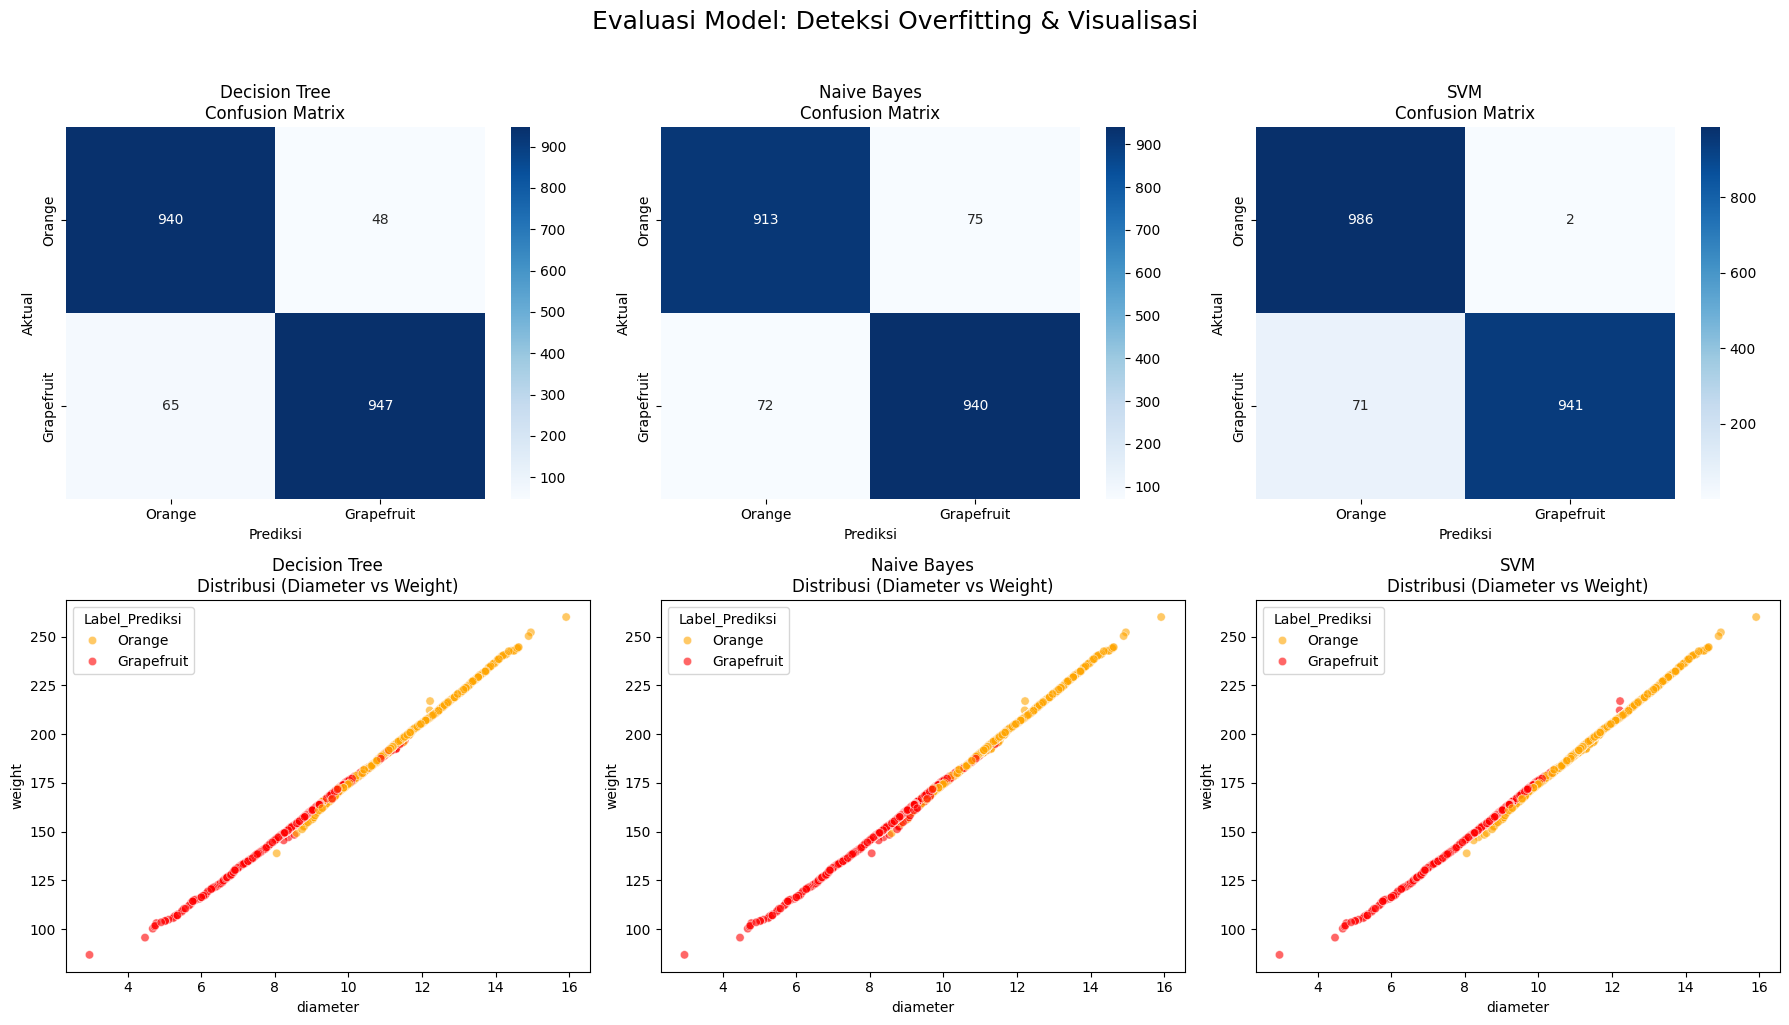

In [5]:
# 5. Evaluation (Revised with Training vs Testing Check)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Evaluasi Model: Deteksi Overfitting & Visualisasi', fontsize=18, y=1.02)

target_names = ['Orange (0)', 'Grapefruit (1)']
col_idx = 0

for name, model in best_models.items():
    # 1. Prediksi Data Latih & Uji
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    # 2. Print Teks Evaluasi & Cek Overfitting
    print(f"\n--- ANALISIS PERFORMA: {name.upper()} ---")
    print(f"Akurasi Training : {train_acc * 100:.2f}%")
    print(f"Akurasi Testing  : {test_acc * 100:.2f}%")
    
    gap = (train_acc - test_acc) * 100
    if gap > 5.0:
        print(f"Status           : TERINDIKASI OVERFITTING (Gap: {gap:.2f}%)")
    elif gap < -2.0:
        print(f"Status           : TERINDIKASI UNDERFITTING")
    else:
        print(f"Status           : GOOD FIT (Generalisasi Sangat Baik)")
        
    print(classification_report(y_test, y_test_pred, target_names=target_names))
    
    # 3. VISUALISASI: Heatmap Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, col_idx],
                xticklabels=['Orange', 'Grapefruit'], 
                yticklabels=['Orange', 'Grapefruit'])
    axes[0, col_idx].set_title(f'{name}\nConfusion Matrix')
    axes[0, col_idx].set_xlabel('Prediksi')
    axes[0, col_idx].set_ylabel('Aktual')
    
    # 4. VISUALISASI: Scatter Plot Prediksi
    df_plot = X_test.copy()
    df_plot['Label_Prediksi'] = pd.Series(y_test_pred).map({0: 'Orange', 1: 'Grapefruit'}).values
    
    sns.scatterplot(data=df_plot, x='diameter', y='weight', hue='Label_Prediksi', 
                    palette={'Orange': 'orange', 'Grapefruit': 'red'}, 
                    alpha=0.6, ax=axes[1, col_idx])
    axes[1, col_idx].set_title(f'{name}\nDistribusi (Diameter vs Weight)')
    
    col_idx += 1

plt.tight_layout()
plt.show()